# Análisis Cuantitativo de Vulnerabilidades

Este notebook carga los reportes JSON generados por **Grype** (SCA) y **Trivy** (SAST/secretos) y crea visualizaciones comparativas.

In [9]:
# ---------------------------------
# Imports
# ---------------------------------
import os, json, glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from IPython import get_ipython
    if get_ipython():
        get_ipython().run_line_magic('matplotlib', 'inline')
except:
    pass

In [10]:
# ---------------------------------
# Paths and file listing
# ---------------------------------
if os.path.exists('analysis_results'):
    BASE_DIR = os.getcwd()
elif os.path.exists('../analysis_results'):
    BASE_DIR = os.path.abspath('..')
else:
    BASE_DIR = '/home/francisco/Documentos/SBOM'

GRYPE_DIR = os.path.join(BASE_DIR, 'analysis_results', 'grype')
TRIVY_DIR = os.path.join(BASE_DIR, 'analysis_results', 'trivy')

grype_files = glob.glob(os.path.join(GRYPE_DIR, '*_grype.json'))
trivy_files = glob.glob(os.path.join(TRIVY_DIR, '*_trivy.json'))

print(f"BASE_DIR detectado: {BASE_DIR}")
print(f"Se encontraron {len(grype_files)} archivos de Grype y {len(trivy_files)} de Trivy")

BASE_DIR detectado: /home/francisco/Documentos/SBOM
Se encontraron 9 archivos de Grype y 9 de Trivy


In [11]:
def load_grype(path):
    with open(path) as f:
        data = json.load(f)
    repo = os.path.basename(path).replace('_grype.json', '')
    rows = []
    for match in data.get('matches', []):
        vuln = match.get('vulnerability', {})
        rows.append({
            'repo': repo,
            'tool': 'grype',
            'severity': str(vuln.get('severity', 'UNKNOWN')).upper(),
            'package': match.get('artifact', {}).get('name'),
            'version': match.get('artifact', {}).get('version'),
            'type': 'dependency'
        })
    return pd.DataFrame(rows)

def load_trivy(path):
    with open(path) as f:
        data = json.load(f)
    repo = os.path.basename(path).replace('_trivy.json', '')
    rows = []
    for result in data.get('Results', []):
        target = result.get('Target')
        for vuln in result.get('Vulnerabilities', []):
            rows.append({
                'repo': repo,
                'tool': 'trivy',
                'severity': str(vuln.get('Severity', 'UNKNOWN')).upper(),
                'package': vuln.get('PkgName'),
                'version': vuln.get('InstalledVersion'),
                'type': 'vulnerability',
                'target': target
            })
        for secret in result.get('Secrets', []):
            rows.append({
                'repo': repo,
                'tool': 'trivy',
                'severity': str(secret.get('Severity', 'UNKNOWN')).upper(),
                'package': secret.get('RuleID'),
                'version': None,
                'type': 'secret',
                'target': target
            })
    return pd.DataFrame(rows)

In [12]:
frames = []
for f in grype_files:
    frames.append(load_grype(f))
for f in trivy_files:
    frames.append(load_trivy(f))

if not frames:
    print("ADVERTENCIA: No se encontraron datos para cargar.")
    all_df = pd.DataFrame(columns=['repo', 'tool', 'severity', 'package', 'version', 'type', 'target'])
else:
    all_df = pd.concat(frames, ignore_index=True)

severity_order = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'UNKNOWN']
all_df['severity'] = all_df['severity'].fillna('UNKNOWN').apply(lambda x: x if x in severity_order else 'UNKNOWN')
all_df['severity'] = pd.Categorical(all_df['severity'], categories=severity_order, ordered=True)

print('Total de registros cargados:', len(all_df))
if not all_df.empty:
    display(all_df.head())

Total de registros cargados: 244


,repo,tool,severity,package,version,type,target
0,playwright-trace-viewer,grype,HIGH,vite,6.4.1,dependency,NaN
1,playwright-trace-viewer,grype,MEDIUM,vite,6.4.1,dependency,NaN
2,playwright-trace-viewer,grype,CRITICAL,playwright-internal,1.60.0-next,dependency,NaN
3,checkly-cli,grype,MEDIUM,picomatch,4.0.3,dependency,NaN
4,checkly-cli,grype,MEDIUM,picomatch,4.0.3,dependency,NaN


In [13]:
if not all_df.empty:
    summary = all_df.groupby(['tool', 'severity'], observed=False).size().reset_index(name='count')
    display(summary)

,tool,severity,count
0,grype,CRITICAL,7
1,grype,HIGH,53
2,grype,MEDIUM,54
3,grype,LOW,10
4,grype,UNKNOWN,0
5,trivy,CRITICAL,9
6,trivy,HIGH,41
7,trivy,MEDIUM,60
8,trivy,LOW,10
9,trivy,UNKNOWN,0


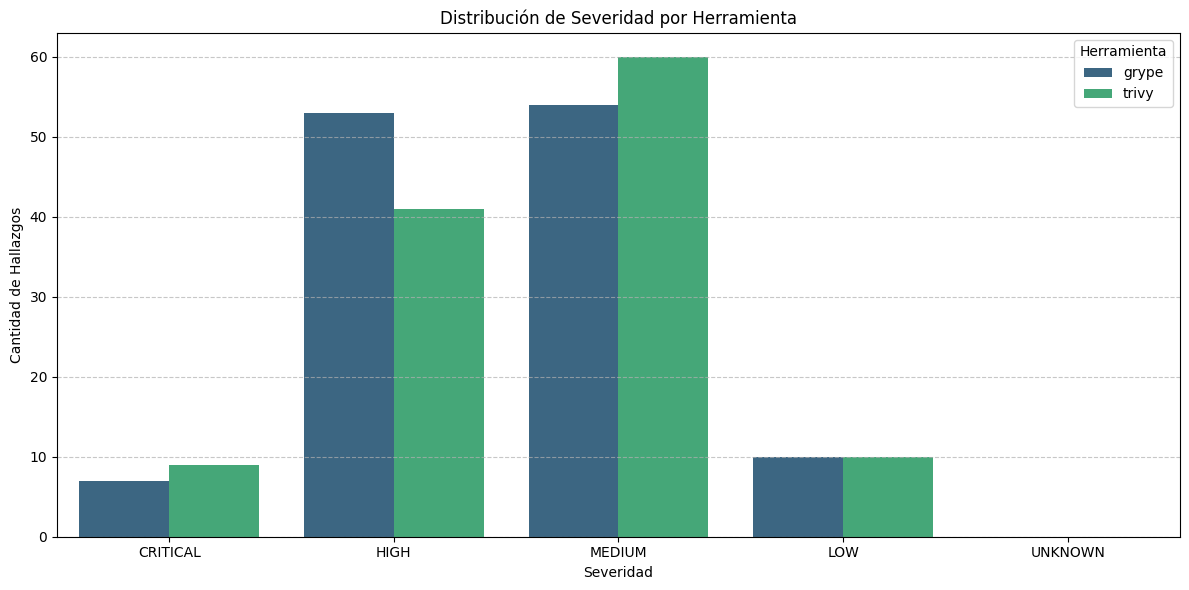

In [14]:
if not all_df.empty:
    plt.figure(figsize=(12,6))
    sns.countplot(data=all_df, x='severity', hue='tool', order=severity_order, palette='viridis')
    plt.title('Distribución de Severidad por Herramienta')
    plt.xlabel('Severidad')
    plt.ylabel('Cantidad de Hallazgos')
    plt.legend(title='Herramienta')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

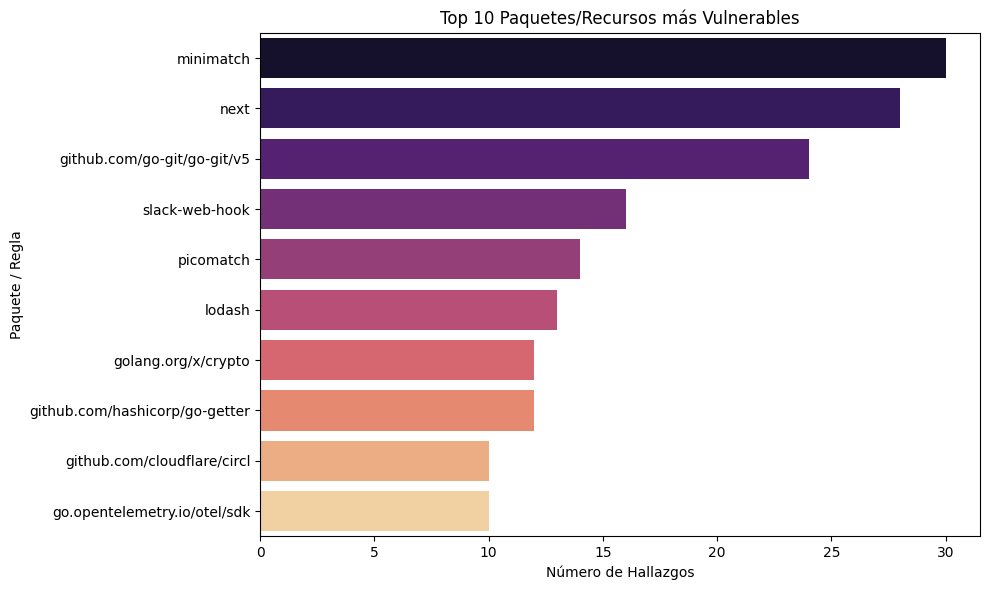

In [15]:
if not all_df.empty:
    top_pkgs = (all_df.groupby('package').size().reset_index(name='count')
                .sort_values('count', ascending=False).head(10))
    plt.figure(figsize=(10,6))
    # Fix FutureWarning: Assign 'package' to hue and legend=False
    sns.barplot(data=top_pkgs, y='package', x='count', hue='package', palette='magma', legend=False)
    plt.title('Top 10 Paquetes/Recursos más Vulnerables')
    plt.xlabel('Número de Hallazgos')
    plt.ylabel('Paquete / Regla')
    plt.tight_layout()
    plt.show()

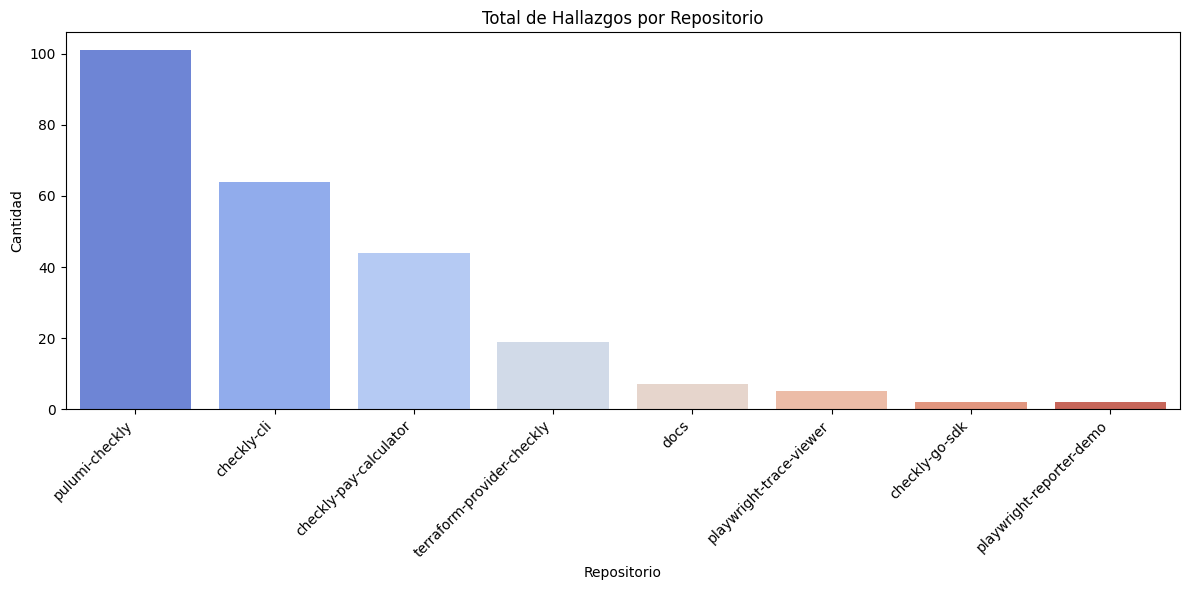

In [16]:
if not all_df.empty:
    repo_counts = (all_df.groupby('repo').size().reset_index(name='count')
                   .sort_values('count', ascending=False))
    plt.figure(figsize=(12,6))
    # Fix FutureWarning: Assign 'repo' to hue and legend=False
    sns.barplot(data=repo_counts, x='repo', y='count', hue='repo', palette='coolwarm', legend=False)
    plt.title('Total de Hallazgos por Repositorio')
    plt.xlabel('Repositorio')
    plt.ylabel('Cantidad')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

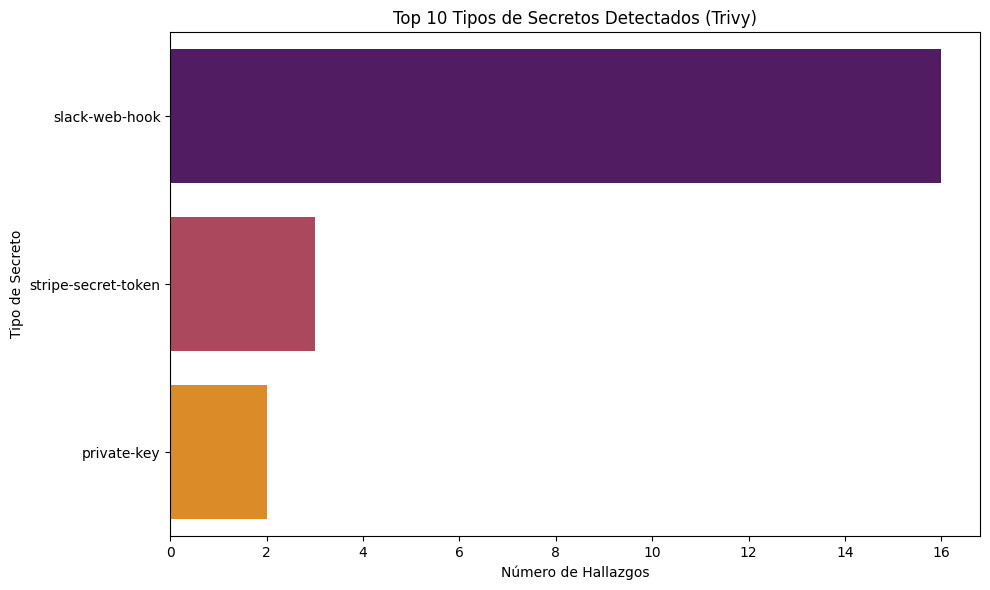

In [17]:
if not all_df.empty:
    secrets_df = all_df[all_df['type'] == 'secret']
    if not secrets_df.empty:
        secret_counts = (secrets_df.groupby('package').size().reset_index(name='count')
                         .sort_values('count', ascending=False).head(10))
        plt.figure(figsize=(10,6))
        # Fix FutureWarning: Assign 'package' to hue and legend=False
        sns.barplot(data=secret_counts, y='package', x='count', hue='package', palette='inferno', legend=False)
        plt.title('Top 10 Tipos de Secretos Detectados (Trivy)')
        plt.xlabel('Número de Hallazgos')
        plt.ylabel('Tipo de Secreto')
        plt.tight_layout()
        plt.show()
    else:
        print('No se encontraron secretos en los reportes de Trivy.')